# Práctica 5

Contenidos: Series de potencias y series de Fourier.

Bibliografía:  https://pythonnumericalmethods.berkeley.edu/notebooks/Index.html

              J. M. Stewart, Python for scientists. Cambridge University Press.

## Series de potencias

Con el comando de Sympy sy.series podemos calcular el desarrollo en serie de 
potencias de una función. Veamos algunos ejemplos. Antes cargaremos los módulos
que necesitaremos.

sympy.series.series.series(expr, x=None, x0=0, n=6, dir='+')

In [5]:
import numpy as np
import sympy as sy
from matplotlib import pyplot as plt
from scipy.integrate import simpson
import math

In [40]:
x = sy.symbols('x')
f = sy.tan(x)
sy.series(f, x, 2, 6, "+")

tan(2) + (1 + tan(2)**2)*(x - 2) + (x - 2)**2*(tan(2)**3 + tan(2)) + (x - 2)**3*(1/3 + 4*tan(2)**2/3 + tan(2)**4) + (x - 2)**4*(tan(2)**5 + 5*tan(2)**3/3 + 2*tan(2)/3) + (x - 2)**5*(2/15 + 17*tan(2)**2/15 + 2*tan(2)**4 + tan(2)**6) + O((x - 2)**6, (x, 2))

In [41]:
x = sy.symbols('x')
funcion1 = sy.exp(sy.sin(x))
funcion1

exp(sin(x))

In [42]:
x = sy.symbols('x')
f1 = sy.fps(sy.exp(x))   #Series de potencias
f2 = sy.fps(sy.sin(x))

In [43]:
f1

FormalPowerSeries(exp(x), x, 0, 1, (SeqFormula(Piecewise((1/factorial(_k), Eq(Mod(_k, 1), 0)), (0, True)), (_k, 1, oo)), SeqFormula(x**_k, (_k, 0, oo)), 1))

In [44]:
f2

FormalPowerSeries(sin(x), x, 0, 1, (SeqFormula(Piecewise(((-1/4)**(_k/2 - 1/2)/(RisingFactorial(3/2, _k/2 - 1/2)*factorial(_k/2 - 1/2)), Eq(Mod(_k, 2), 1)), (0, True)), (_k, 2, oo)), SeqFormula(x**_k, (_k, 0, oo)), x))

In [45]:
f1.truncate(n=8)

1 + x + x**2/2 + x**3/6 + x**4/24 + x**5/120 + x**6/720 + x**7/5040 + O(x**8)

Para componer funciones disponemos del comando compose.

In [46]:
f1.compose(f2,x).truncate()

1 + x + x**2/2 - x**4/8 - x**5/15 + O(x**6)

Ejercicio 29

In [47]:
x = sy.symbols("x")
f1 = sy.fps(x * sy.exp(x - 1), x0 = 1)
polinomiotaylor2 = f1.truncate(n=10)
polinomiotaylor2

-1 + 3*(x - 1)**2/2 + 2*(x - 1)**3/3 + 5*(x - 1)**4/24 + (x - 1)**5/20 + 7*(x - 1)**6/720 + (x - 1)**7/630 + (x - 1)**8/4480 + (x - 1)**9/36288 + 2*x + O((x - 1)**10, (x, 1))

In [48]:
x = sy.symbols("x")
f1 = sy.fps(x**3 * sy.log(x), x0 = 1)
polinomiotaylor2 = f1.truncate(n=10)
polinomiotaylor2

-1 + 5*(x - 1)**2/2 + 11*(x - 1)**3/6 + (x - 1)**4/4 - (x - 1)**5/20 + (x - 1)**6/60 - (x - 1)**7/140 + (x - 1)**8/280 - (x - 1)**9/504 + x + O((x - 1)**10, (x, 1))

Ejercicio 30

In [49]:
derivadas = []
for i in range(3):
    a = sy.diff((1 - x)**(1/3), x, 1)
    derivadas.append(a)

In [50]:
polinomiostaylornew = sum(derivadas[i]/math.factorial(i)*x**i for i in range(3))

In [51]:
polinomiostaylornew.subs(x, 0.03)

-0.350529451017617

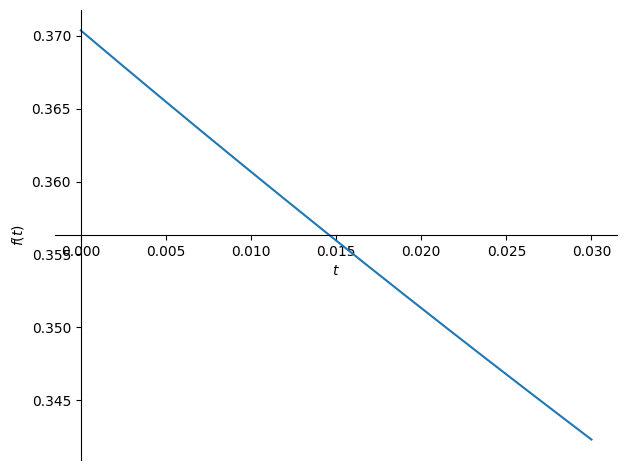

In [52]:
x, t = sy.symbols("x t")
sy.plot(sy.diff((1+x)**(1/3),x,3).subs(x, t),(t, 0, 0.03))

In [53]:
0.4/math.factorial(3)* (0.03)**3

1.7999999999999997e-06

In [54]:
(1.03)**(1/3)

1.009901634049961

Ejercico 31

In [55]:
derivada1= []
for i in range(5):
    a = sy.diff(sy.log(sy.cos(2*x)),x,i)
    derivada1.append(a.subs(x,0))
derivada2= []
for i in range(5):
    b = sy.diff(sy.log(sy.cos(3*x)),x,i)
    derivada2.append(b.subs(x,0))

In [56]:
sum(derivada1[i]/math.factorial(i) * x**i for i in range(5))/sum(derivada2[i]/math.factorial(i) * x**i for i in range(5))

(-4*x**4/3 - 2*x**2)/(-27*x**4/4 - 9*x**2/2)

Ejercicio 52

In [57]:
for i in range(20):
    a = sy.diff((sy.exp(2*x),x,1),x,i)
    if (a<=1/1000):
        print(i)

AttributeError: 'float' object has no attribute 'args'

## Series de Fourier

Podemos utilizar diferentes recursos para trabajar con series de Fourier con 
Python. Una opción es definir nuestras propias funciones. 

Recuerda:
$$f(x)=\frac{A_0}{2}+\sum_{n=1}^\infty A_n\, \cos(nx)+B_n\,\sin(nx).$$
Siendo
$$A_n=\frac{1}{\pi}\int_{-\pi}^{\pi} f(x) \cos(nx)\,dx,$$
$$B_n=\frac{1}{\pi}\int_{-\pi}^{\pi} f(x)\sin(nx)\,dx.$$


In [11]:
def my_fourier_coef(f,n):
    x = np.linspace(-np.pi, np.pi, 1001)
    y1 = f(x)*np.cos(n*x)
    y2 = f(x)*np.sin(n*x)
    return([1/np.pi*simpson(y1, x), 1/np.pi*simpson(y2, x)])

In [8]:
def f(x):
    return(np.sin(np.exp(x)))

In [9]:
def plot_results(f, N):
    x = np.linspace(-np.pi, np.pi, 1000)
    [A0, B0] = my_fourier_coef(f, 0)
    y = A0*np.ones(len(x))/2
    for n in range (1, N):
        [An, Bn] = my_fourier_coef(f, n)
        y += An*np.cos(n*x)+Bn*np.sin(n*x)
    plt.figure(figsize= (10,6))
    plt.plot(x, f(x), label = 'analítica')
    plt.plot(x,y, label = 'aproximación')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid()
    plt.legend()
    plt.title(f'{N}-ésimo aproximación de Fourier')
    plt.show()



In [12]:

plot_results(f, 2)

TypeError: simpson() takes 1 positional argument but 2 were given

Si aumentamos el orden de la serie:

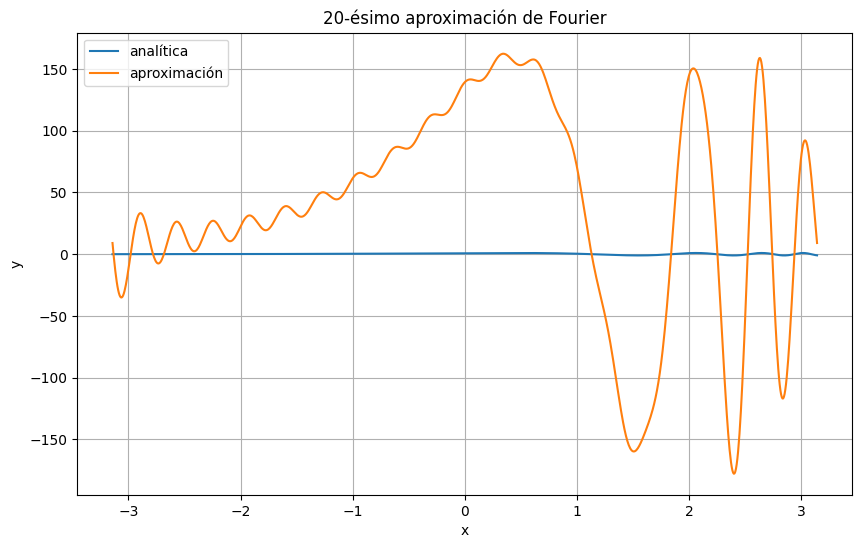

In [10]:
plot_results(f,20)

Veamos otros ejemplos

In [13]:
f = lambda x: np.mod(x, np.pi/2)

Utiliza la función anterior y representa su aproximación de Fourier de orden 5 y
orden 20. Repite el procedimiento con la función:

In [ ]:
x = np.linspace(-np.pi,np.pi, 1000)

In [ ]:
f2 = lambda x: (x > -np.pi/2) & (x < np.pi/2)

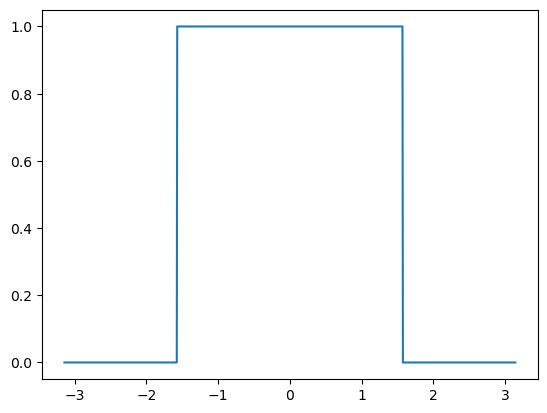

In [ ]:
plt.plot(x,f2(x))

La otra posibilidad nos la proporciona Sympy que nos ofrece la opción de 
calcular directamente con el comando que ofrece la serie de Fourier.
Veamos un ejemplo

In [ ]:
x = sy.symbols('x')
serie1 = sy.fourier_series(x**2, (x, -sy.pi, sy.pi))

In [ ]:
serie1

FourierSeries(x**2, (x, -pi, pi), (pi**2/3, SeqFormula(Piecewise((2*pi**2*sin(_n*pi)/_n + 4*pi*cos(_n*pi)/_n**2 - 4*sin(_n*pi)/_n**3, (_n > -oo) & (_n < oo) & Ne(_n, 0)), (2*pi**3/3, True))*cos(_n*x)/pi, (_n, 1, oo)), SeqFormula(0, (_k, 1, oo))))

In [ ]:
serie1.truncate()

-4*cos(x) + cos(2*x) + pi**2/3

In [ ]:
serie2 =sy.fourier_series(sy.sin(sy.exp(x)),(x,-sy.pi,sy.pi))

In [ ]:
serie2.truncate(n=2)

sin(x)*Integral(sin(x)*sin(exp(x)), (x, -pi, pi))/pi + cos(x)*Integral(sin(exp(x))*cos(x), (x, -pi, pi))/pi + Integral(sin(exp(x)), (x, -pi, pi))/(2*pi)

In [ ]:
x = sy.Symbol('x', real=True)
ejercicio5 = sy.Piecewise(
    (0, x < -sy.pi/2),
    (1, x > -sy.pi/2)
)
series = sy.fourier_series(ejercicio5, (x, -sy.pi, sy.pi))

In [ ]:
series

FourierSeries(Piecewise((0, x < -pi/2), (1, x > -pi/2)), (x, -pi, pi), (3/4, SeqFormula(Piecewise((sin(_n*pi/2)/_n + sin(_n*pi)/_n, (_n > -oo) & (_n < oo) & Ne(_n, 0)), (3*pi/2, True))*cos(_n*x)/pi, (_n, 1, oo)), SeqFormula(Piecewise((cos(_n*pi/2)/_n - cos(_n*pi)/_n, (_n > -oo) & (_n < oo) & Ne(_n, 0)), (0, True))*sin(_n*x)/pi, (_n, 1, oo))))

In [ ]:
series.truncate(n = 5)

sin(x)/pi - sin(2*x)/pi + sin(3*x)/(3*pi) + sin(5*x)/(5*pi) + cos(x)/pi - cos(3*x)/(3*pi) + cos(5*x)/(5*pi) + 3/4

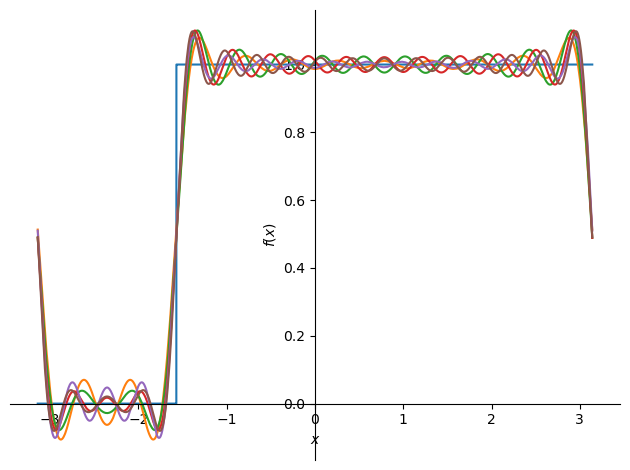

In [ ]:
p = sy.plot(ejercicio5, (x, -sy.pi, sy.pi), show=False, label='$ejercicio5(x)$')
for i in range(10, 15):
    p.extend(sy.plot(series.truncate(n = i), (x, -sy.pi, sy.pi),
             show=False, label=f'Suma parcial {i}'))
    
p.show()

ejercicio 5. Fourier

In [ ]:
f3 = lambda

In [ ]:
x = sy.symbols("x")
[A0, B0] = my_fourier_coef(f3, 0)
y = A0/2
for n in range(1,10):
    [An, Bn] = my_fourier_coef(f3, n)
    y += An * sy.cos(n*x) + Bn * sy.sin(n*x)

In [ ]:
dibujo1 = sy.plot(y,(x, -sy.pi, sy.pi), show=False)
dibujo2 = sy.plot(y,(x, -sy.pi, sy.pi), show=False)
dibujo2.append(dibujo1[0])
dibujo2.show()

ejercicio 6

In [14]:
t = sy.symbols("t")
fs6 = sy.fourier_series(sy.Piecewise((1, t <= 5), (2, t > 5)), (t, 4, 6))

In [20]:
fs6.truncate(5)

-2*sin(pi*t)/pi - 2*sin(3*pi*t)/(3*pi) - 2*sin(5*pi*t)/(5*pi) - 2*sin(7*pi*t)/(7*pi) + 3/2

In [24]:
fs7 = sy.fourier_series(sy.Piecewise((0, t>1/2), (1, t<1/2), (0, t<-1/2)), (t, -1, 1))

In [26]:
fs7.truncate(8)

-sin(pi*t)/pi + sin(2*pi*t)/pi - sin(3*pi*t)/(3*pi) - sin(5*pi*t)/(5*pi) + sin(6*pi*t)/(3*pi) - sin(7*pi*t)/(7*pi) - sin(9*pi*t)/(9*pi) + cos(pi*t)/pi - cos(3*pi*t)/(3*pi) + cos(5*pi*t)/(5*pi) - cos(7*pi*t)/(7*pi) + cos(9*pi*t)/(9*pi) + 0.75